In [1]:
import pandas as pd

merging the dataset into one big dataset

In [3]:
clean_barcelona = pd.read_excel("/Users/margheritatonon/COMP P 2/dataviz_compp_assignment/clean_barcelona.xlsx")
clean_malasaña = pd.read_excel("/Users/margheritatonon/COMP P 2/dataviz_compp_assignment/clean_malasaña.xlsx")
clean_mallorca = pd.read_excel("/Users/margheritatonon/COMP P 2/dataviz_compp_assignment/clean_mallorca.xlsx")
clean_pozuelo = pd.read_excel("/Users/margheritatonon/COMP P 2/dataviz_compp_assignment/clean_pozuelo.xlsx")
clean_valencia = pd.read_excel("/Users/margheritatonon/COMP P 2/dataviz_compp_assignment/clean_valencia.xlsx")

In [4]:
citiesdataframe = pd.concat([clean_barcelona, clean_malasaña, clean_mallorca, clean_pozuelo, clean_valencia], ignore_index=True)

# Pie Chart

In [5]:
import matplotlib.pyplot as plt
from plotnine import *

([<matplotlib.patches.Wedge object at 0x16870fd70>, <matplotlib.patches.Wedge object at 0x16870c7a0>, <matplotlib.patches.Wedge object at 0x16878e2a0>, <matplotlib.patches.Wedge object at 0x16878db20>, <matplotlib.patches.Wedge object at 0x16878cbf0>], [Text(0.9138855058165651, 0.6122199623161605, 'BARCELONA'), Text(0.10409662222764238, 1.0950634197345812, 'MALASAÑA'), Text(-0.6087441741769356, 0.9162044151856292, 'MALLORCA'), Text(-1.08513341717049, -0.5123333552872535, 'POZUELO'), Text(0.7420765957909923, -0.8119866538184309, 'VALENCIA')], [Text(0.49848300317267186, 0.33393816126336023, '18.8%'), Text(0.056779975760532196, 0.5973073198552261, '9.4%'), Text(-0.332042276823783, 0.49974786282852496, '12.3%'), Text(-0.6329944933494526, -0.2988611239175646, '33.1%'), Text(0.4047690522496321, -0.44290181117368954, '26.4%')])


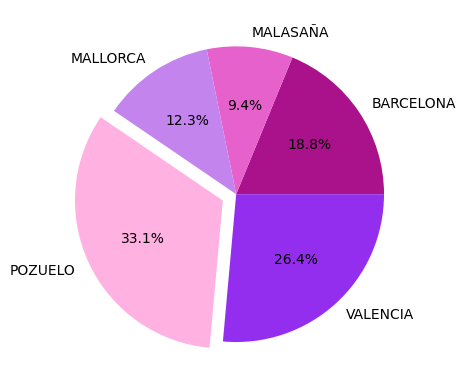

In [6]:
#pie chart with the local to see how many are the same
data1 = citiesdataframe[["Local", "index"]].groupby(by = "Local", as_index=False).count()
pie = plt.pie(data1["index"], labels = data1["Local"], colors = ["#A9128B", "#E761CD", "#C484EE", "#FFB2E1", "#942EEE"], autopct = "%.1f%%", explode = [0, 0, 0, 0.1, 0])
print(pie)

# Lollipop

In [7]:
#lollipop city vs number
data2 = citiesdataframe[["City", "index"]].groupby(by = "City", as_index=False).count()
data2

,City,index
0,Alcorcón,18
1,Barcelona,110
2,Cornella de Llobregat,6
3,La Navata,12
4,Madrid,57
5,Majadahona,2
6,Manises,6
7,Palma de Mallorca,102
8,Paterna,4
9,Pontevedra,3


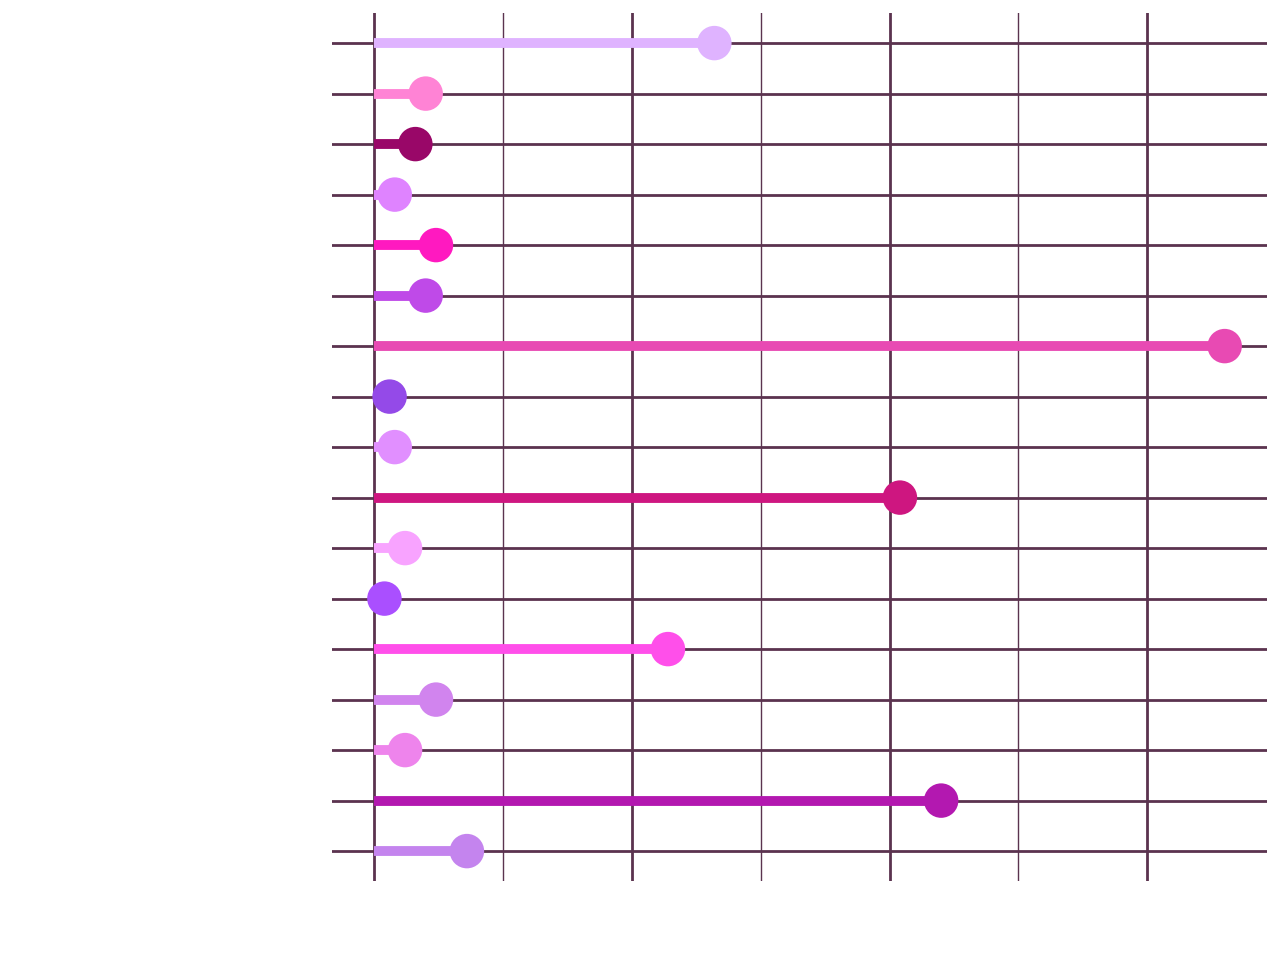

In [8]:
ggplot(aes("City", "index", fill = "City", color = "City"), data2) + geom_point(size = 6) + geom_segment(aes(x="City", xend="City", y=0, yend="index"), size = 2)\
      + coord_flip() + theme_minimal() + scale_fill_manual(["#C484EE", "#B318B0" , "#EE84EC", "#D184EE", "#FF4FEA", "#AA4FFF", "#F8A3FF", "#CE1680", "#E18FFF", "#944AE8","#E84AB3", "#BF4AE8", "#FF19C0", "#DF83FF", "#990768", "#FF83D5", "#DFB3FF"])\
      + scale_color_manual(["#C484EE", "#B318B0" , "#EE84EC", "#D184EE", "#FF4FEA", "#AA4FFF", "#F8A3FF", "#CE1680", "#E18FFF", "#944AE8","#E84AB3", "#BF4AE8", "#FF19C0", "#DF83FF", "#990768", "#FF83D5", "#DFB3FF"])\
      + theme(axis_text_x= element_text(color = "white")) + theme(axis_text_y= element_text(color = "white")) + theme(axis_title_x= element_text(color = "white")) + theme(axis_title_y= element_text(color = "white"))\
      + theme(plot_title = element_text(color = "white")) + theme(legend_position = "none") + ylab("Number of Sales") + theme(panel_grid=element_line(color = "#5B334F"))

# pd melt with city names and number of product family

In [9]:
#now doing a pd corr between the product family and city to see if there is a correlation between them

In [10]:
citiesdataframe.columns

Index(['index', 'Date', 'Number', 'Local', 'Terminal Point of Sale', 'Center',
       'Location', 'Date of Creation', 'Type of Document', 'Client',
       'Client ID', 'Cuenta Contable', 'City', 'Province', 'Street',
       'Postal Code', 'Client Name', 'Manufacturing Line', 'Type of Product',
       'Product Family', 'Product', 'Quantity', 'Precio Coste', 'Price',
       'Discount in %', 'Discount in €', 'Promotional Code', 'Discount Code',
       'Tax in %', 'Surcharge in %', 'Base Price', 'Total Price',
       'Ticket Discount in €', 'Ticket Discount in %'],
      dtype='object')

In [11]:
citiesdataframe["City"].unique()

array([nan, 'Barcelona', 'Cornella de Llobregat', 'Palma de Mallorca',
       'Madrid', 'Pozuelo de Alarcon', 'Santa Cruz de Tenerife',
       'Sevilla', 'Pontevedra', 'Majadahona', 'La Navata', 'Alcorcón',
       'Roa', 'Puerto de Sagunto', 'Valencia', 'Manises', 'Sant Cugat',
       'Paterna'], dtype=object)

In [12]:
cross = pd.crosstab(citiesdataframe["Product Family"], citiesdataframe["City"])
cross["Product Family"] = cross.index
cross

City,Alcorcón,Barcelona,Cornella de Llobregat,La Navata,Madrid,Majadahona,Manises,Palma de Mallorca,Paterna,Pontevedra,Pozuelo de Alarcon,Puerto de Sagunto,Roa,Sant Cugat,Santa Cruz de Tenerife,Sevilla,Valencia,Product Family
Product Family,,,,,,,,,,,,,,,,,,
Alcohol,3,2,1,0,0,0,0,19,0,1,17,1,0,0,1,1,4,Alcohol
BBQ,0,3,0,0,2,0,0,3,0,0,10,1,0,0,0,0,6,BBQ
Bao,0,3,0,0,7,0,0,9,0,1,20,0,0,1,0,1,4,Bao
Coffee and Tea,2,0,0,0,0,0,0,6,0,1,1,0,0,0,0,0,0,Coffee and Tea
Compra,7,25,1,5,10,1,3,24,1,0,23,2,3,1,1,2,13,Compra
Dessert,0,0,0,0,1,0,0,2,0,0,4,0,0,0,0,0,4,Dessert
Drinks,1,1,0,0,9,0,0,13,1,0,18,3,3,0,1,2,12,Drinks
Extras,0,2,0,3,2,0,0,0,0,0,4,0,0,0,0,0,0,Extras
Noodles,0,29,1,4,8,0,3,7,0,0,19,1,0,2,1,1,10,Noodles


In [13]:
x = pd.melt(cross, id_vars = "Product Family", var_name = "City", value_name = "Count")
x

,Product Family,City,Count
0,Alcohol,Alcorcón,3
1,BBQ,Alcorcón,0
2,Bao,Alcorcón,0
3,Coffee and Tea,Alcorcón,2
4,Compra,Alcorcón,7
...,...,...,...
216,Noodles,Valencia,10
217,Rice Bowl,Valencia,6
218,Soup,Valencia,0
219,Starters,Valencia,1


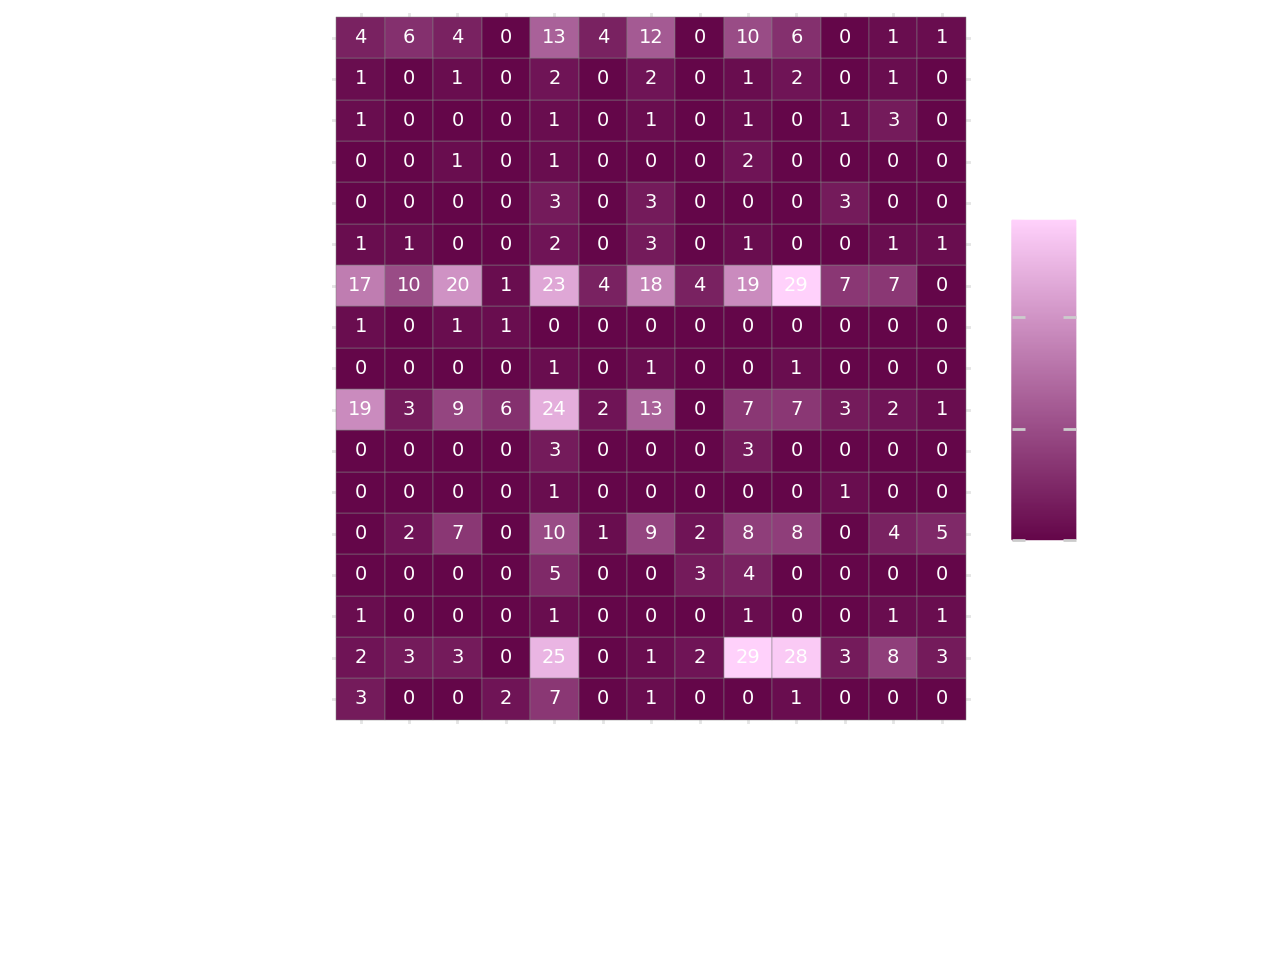

In [14]:
ggplot(aes("Product Family", "City", fill = "Count"), x) + geom_tile(color = "grey")\
+ scale_fill_gradient(low = "#640649", high = "#FFD1FB") + theme_minimal() + theme(axis_text_x=element_text(angle = 90))\
+ theme(axis_text_y= element_text(color = "white")) + theme(axis_text_x= element_text(color = "white"))\
+ theme(axis_title_x= element_text(color = "white")) + theme(axis_title_y= element_text(color = "white"))\
+ theme(legend_title=element_text(color = "white")) + theme(legend_text=element_text(color = "white")) + geom_text(aes(label = "Count"), color = "white", size = 7)\
+ labs(fill="Number of Sales")

In [15]:
#boxplot with product family and price
data3 = citiesdataframe[["Product Family", "Price"]].groupby(by = "Product Family", as_index=False).mean()
citiesdataframe

,index,Date,Number,Local,Terminal Point of Sale,Center,Location,Date of Creation,Type of Document,Client,...,Discount in %,Discount in €,Promotional Code,Discount Code,Tax in %,Surcharge in %,Base Price,Total Price,Ticket Discount in €,Ticket Discount in %
0,0,2019-01-02,TBCN-FS/004623,BARCELONA,TPV Barcelona,NaN,G1,2019-01-02 14:02:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,8.14,8.95,0.0,0.0
1,1,2019-01-02,TBCN-FS/004623,BARCELONA,TPV Barcelona,NaN,G1,2019-01-02 14:02:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,2.73,3.00,0.0,0.0
2,2,2019-01-02,TBCN-FS/004624,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:04:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,8.14,8.95,0.0,0.0
3,3,2019-01-02,TBCN-FS/004624,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:04:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,9.55,10.50,0.0,0.0
4,4,2019-01-02,TBCN-FS/004625,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:09:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,9.55,10.50,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167889,46488,2020-03-18,TV-FS/018146,VALENCIA,TPV Valencia,NaN,D1,2020-03-18 14:23:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,2.73,3.00,2.0,0.0
167890,46489,2020-03-18,TV-FS/018146,VALENCIA,TPV Valencia,NaN,D1,2020-03-18 14:23:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,9.05,9.95,2.0,0.0
167891,46490,2020-03-18,TV-FS/018146,VALENCIA,TPV Valencia,NaN,D1,2020-03-18 14:23:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,0.68,0.75,2.0,0.0
167892,46491,2020-03-18,TV-FS/018147,VALENCIA,TPV Valencia,NaN,G1,2020-03-18 15:26:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,9.05,9.95,0.0,0.0


In [16]:
#we need to remove the rows for null values in this case as we dont want nan to be a category here
boxplotdata = citiesdataframe.dropna(subset = ["City"])
boxplotdata

,index,Date,Number,Local,Terminal Point of Sale,Center,Location,Date of Creation,Type of Document,Client,...,Discount in %,Discount in €,Promotional Code,Discount Code,Tax in %,Surcharge in %,Base Price,Total Price,Ticket Discount in €,Ticket Discount in %
24,24,2019-01-03,TBCN-FS/004635,BARCELONA,TPV Barcelona,Glovo,GL1,2019-01-03 12:42:00,Fra. Simp.,glovo corporate lunch,...,0.0,0.0,NaN,NaN,10,1.4,57.27,63.00,0.0,0.0
31,31,2019-01-03,TBCN-FS/004640,BARCELONA,TPV Barcelona,NaN,G1,2019-01-03 19:57:00,Fra. Simp.,BLANCA LOPEZ CASAS,...,0.0,0.0,NaN,NaN,10,1.4,8.14,8.95,0.0,0.0
44,45,2019-01-04,TBCN-FS/004647,BARCELONA,TPV Barcelona,Glovo,GL1,2019-01-04 12:27:00,Fra. Simp.,glovo de corporate lunch,...,0.0,0.0,NaN,NaN,10,1.4,133.64,147.00,0.0,0.0
231,238,2019-01-08,TBCN-FS/004721,BARCELONA,TPV Barcelona,Glovo,GL1,2019-01-08 12:15:00,Fra. Simp.,glovo corporate lunch,...,0.0,0.0,NaN,NaN,10,1.4,187.14,205.85,0.0,0.0
285,293,2019-01-10,TBCN-FS/004743,BARCELONA,TPV Barcelona,Glovo,GL1,2019-01-10 12:24:00,Fra. Simp.,glovo corporate lunch,...,0.0,0.0,NaN,NaN,10,1.4,89.50,98.45,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163460,41831,2020-01-29,TV-FS/017113,VALENCIA,TPV Valencia,Not Take Away,5,2020-01-29 16:11:00,Fra. Simp.,GIMNASIO CALLE JOAQUIN COSTA,...,0.0,0.0,NaN,NaN,10,1.4,0.00,0.00,0.0,0.0
163461,41832,2020-01-29,TV-FS/017113,VALENCIA,TPV Valencia,Not Take Away,5,2020-01-29 16:11:00,Fra. Simp.,GIMNASIO CALLE JOAQUIN COSTA,...,0.0,0.0,NaN,NaN,10,1.4,0.00,0.00,0.0,0.0
166864,45398,2020-03-03,TV-FS/017889,VALENCIA,TPV Valencia,Not Take Away,13,2020-03-03 14:45:00,Fra. Simp.,ETHIC TROPIC SL,...,0.0,0.0,NaN,NaN,10,1.4,1.82,2.00,0.0,0.0
166865,45399,2020-03-03,TV-FS/017889,VALENCIA,TPV Valencia,Not Take Away,13,2020-03-03 14:45:00,Fra. Simp.,ETHIC TROPIC SL,...,0.0,0.0,NaN,NaN,10,1.4,8.14,8.95,0.0,0.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 3 rows containing non-finite values.


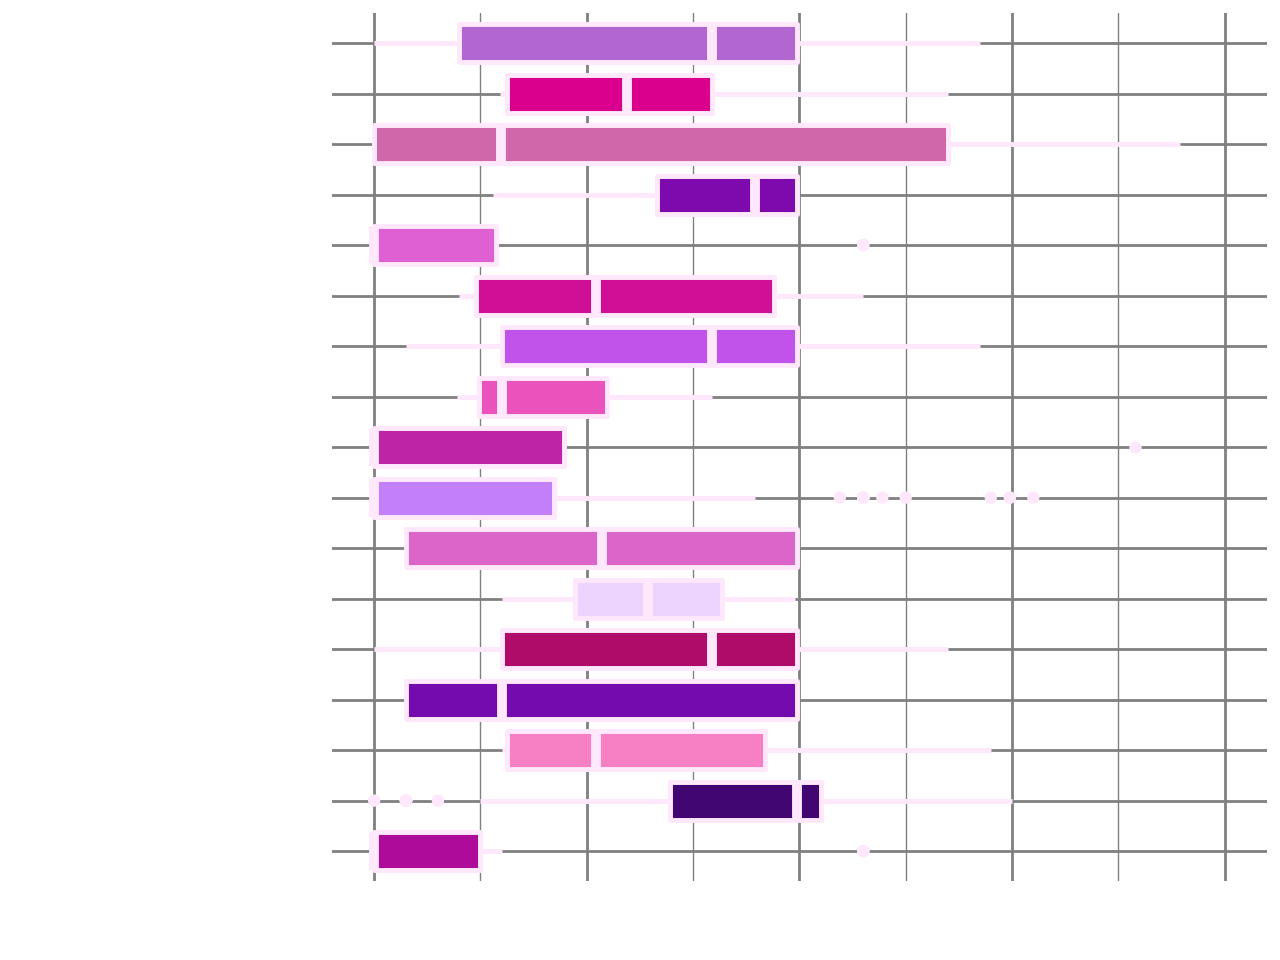

In [17]:
ggplot(aes("City", "Price", fill = "City"), boxplotdata) + geom_boxplot(color = "#FFE7FC", size = 1) + coord_flip() + ylim(0, 20) + theme_minimal()\
+ theme(axis_text_y= element_text(color = "white")) + theme(axis_text_x= element_text(color = "white")) + theme(axis_title_x= element_text(color = "white"))\
+ theme(axis_title_y= element_text(color = "white")) + theme(legend_title=element_text(color = "white")) + theme(legend_text=element_text(color = "white"))\
+ theme(legend_position = "none")\
+ scale_fill_manual(["#AF0B9B", "#410671", "#F77FC3","#730BAF", "#AF0B69", "#ECD4FF", "#DC65CA", "#C27FF7", "#BD24A6", "#EA52BC", "#C152EA", "#CF0F95", "#DF60D2", "#7E0AAD", "#D067AB", "#DA008D", "#B267D0"])\
+ theme(panel_grid=element_line(color = "gray"))

# facet grid with type of product, discount in %, local

In [29]:
citiesdataframe.columns

Index(['index', 'Date', 'Number', 'Local', 'Terminal Point of Sale', 'Center',
       'Location', 'Date of Creation', 'Type of Document', 'Client',
       'Client ID', 'Cuenta Contable', 'City', 'Province', 'Street',
       'Postal Code', 'Client Name', 'Manufacturing Line', 'Type of Product',
       'Product Family', 'Product', 'Quantity', 'Precio Coste', 'Price',
       'Discount in %', 'Discount in €', 'Promotional Code', 'Discount Code',
       'Tax in %', 'Surcharge in %', 'Base Price', 'Total Price',
       'Ticket Discount in €', 'Ticket Discount in %'],
      dtype='object')

In [30]:
citiesdataframe["Product Family"].unique()

array(['Rice Bowl', 'Extras', 'Noodles', 'Compra', 'Drinks', 'Starters',
       'Soup', 'Bao', 'BBQ', 'Thai Curry', nan, 'Alcohol', 'Dessert',
       'Coffee and Tea'], dtype=object)

In [31]:
data4 = citiesdataframe.dropna(subset = ["Product Family"])

In [32]:
data44 = data4[["Product Family", "Local", "Discount in %"]].groupby(by = ["Product Family", "Local"], as_index = False).mean()

In [33]:
ggplot(aes("Product Family", "Discount in %", fill= "Product Family"), data44) + geom_col() + facet_grid(["Local", ""])\
+ theme_minimal() + theme(legend_position = "none") + theme(axis_text_x=element_text(angle = 70)) + theme(panel_grid=element_line(color = "#5B334F"))\
+ theme(axis_text_x=element_text(color = "white")) + theme(axis_text_y=element_text(color = "white")) + theme(axis_title_x=element_text(color = "white"))\
+ theme(axis_title_y=element_text(color = "white")) + scale_fill_manual(["#AF0B9B", "#FDACE1", "#F77FC3","#F2E4FF", "#AF2B69", "#ECD4FF", "#DC65CA", "#FFE4F9", "#DF9CFF", "#FF0EBD", "#C152EA", "#FAB1E6", "#DF60D2"])\
+ theme(text=element_text(color= "white"))

SyntaxError: invalid syntax (<string-expression>, line 0)

/Users/margheritatonon/Library/Python/3.12/lib/python/site-packages/IPython/lib/pretty.py:779: FutureWarning: Using repr(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


SyntaxError: invalid syntax (<string-expression>, line 0)

# Geom Point

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 5 rows containing missing values.


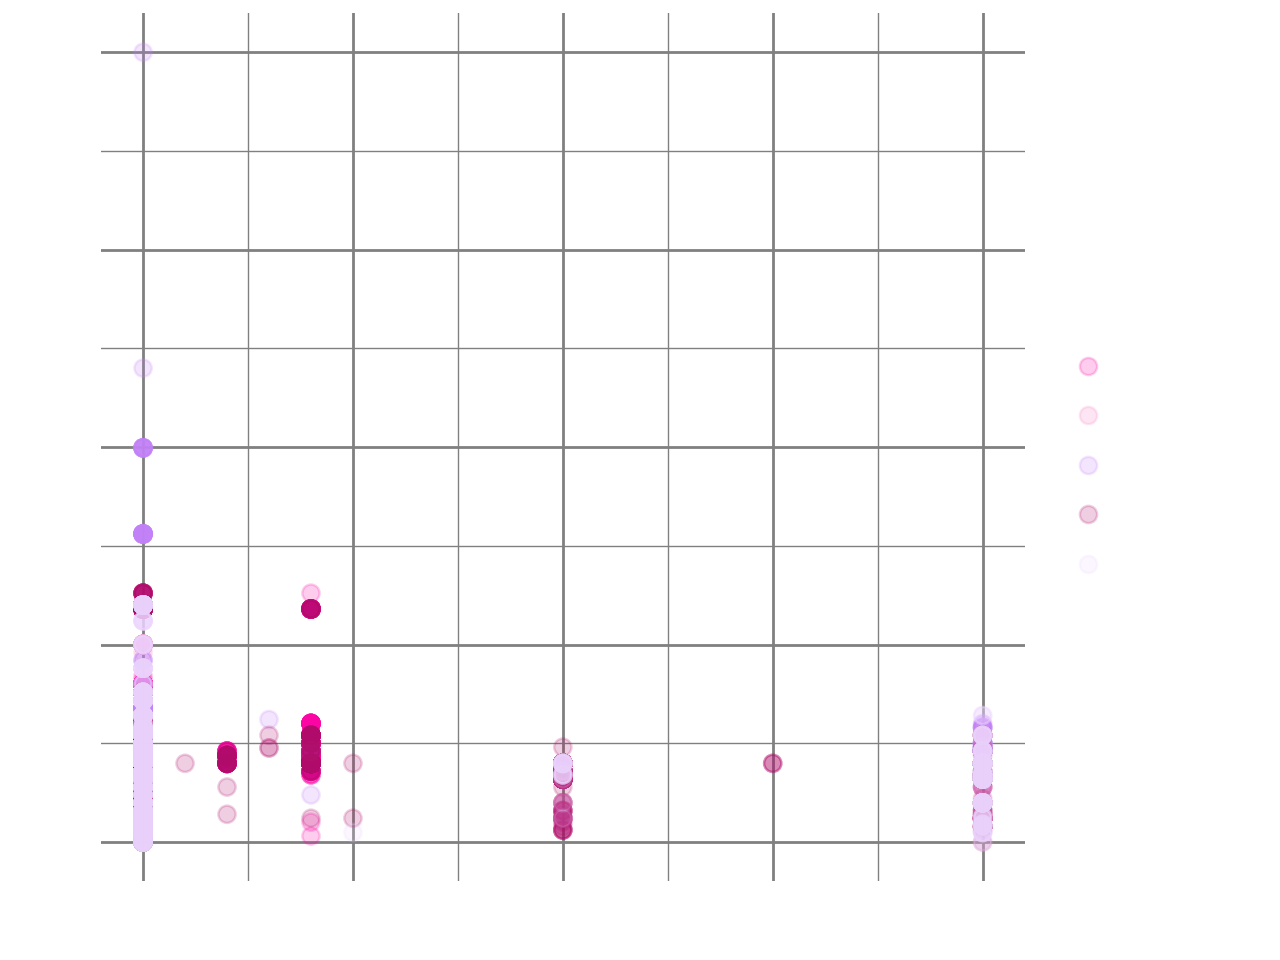

In [34]:
ggplot(aes("Discount in %", "Price", color = "Local"), citiesdataframe) + geom_point(size = 3, alpha = 0.2) + theme_minimal() + theme(axis_text_y= element_text(color = "white")) + theme(axis_text_x= element_text(color = "white")) + theme(axis_title_x= element_text(color = "white"))\
+ theme(axis_title_y= element_text(color = "white")) + theme(legend_title=element_text(color = "white")) + theme(legend_text=element_text(color = "white"))\
+ scale_color_manual(["#FC02A4", "#F77FC3", "#C27FF7", "#AF0B69", "#ECD4FF"]) + theme(panel_grid=element_line(color = "gray"))

# violin plot of price per type of product

In [35]:
citiesdataframe.columns

Index(['index', 'Date', 'Number', 'Local', 'Terminal Point of Sale', 'Center',
       'Location', 'Date of Creation', 'Type of Document', 'Client',
       'Client ID', 'Cuenta Contable', 'City', 'Province', 'Street',
       'Postal Code', 'Client Name', 'Manufacturing Line', 'Type of Product',
       'Product Family', 'Product', 'Quantity', 'Precio Coste', 'Price',
       'Discount in %', 'Discount in €', 'Promotional Code', 'Discount Code',
       'Tax in %', 'Surcharge in %', 'Base Price', 'Total Price',
       'Ticket Discount in €', 'Ticket Discount in %'],
      dtype='object')

In [36]:
data5 = citiesdataframe[["Type of Product", "Price"]].dropna(subset = ["Type of Product"])
data5

,Type of Product,Price
33476,Food,1.00
33480,Food,1.00
33482,Food,2.00
33524,Food,1.00
33629,Food,1.00
...,...,...
152292,Food,0.75
152337,Food,1.20
157506,Food,1.50
157641,Food,1.50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_ydensity : Removed 1 rows containing non-finite values.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_jitter : Removed 1 rows containing missing values.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/guides/guides.py:190: PlotnineWarning: Cannot generate legend for the 'color' aesthetic. Make sure you have mapped a variable to it


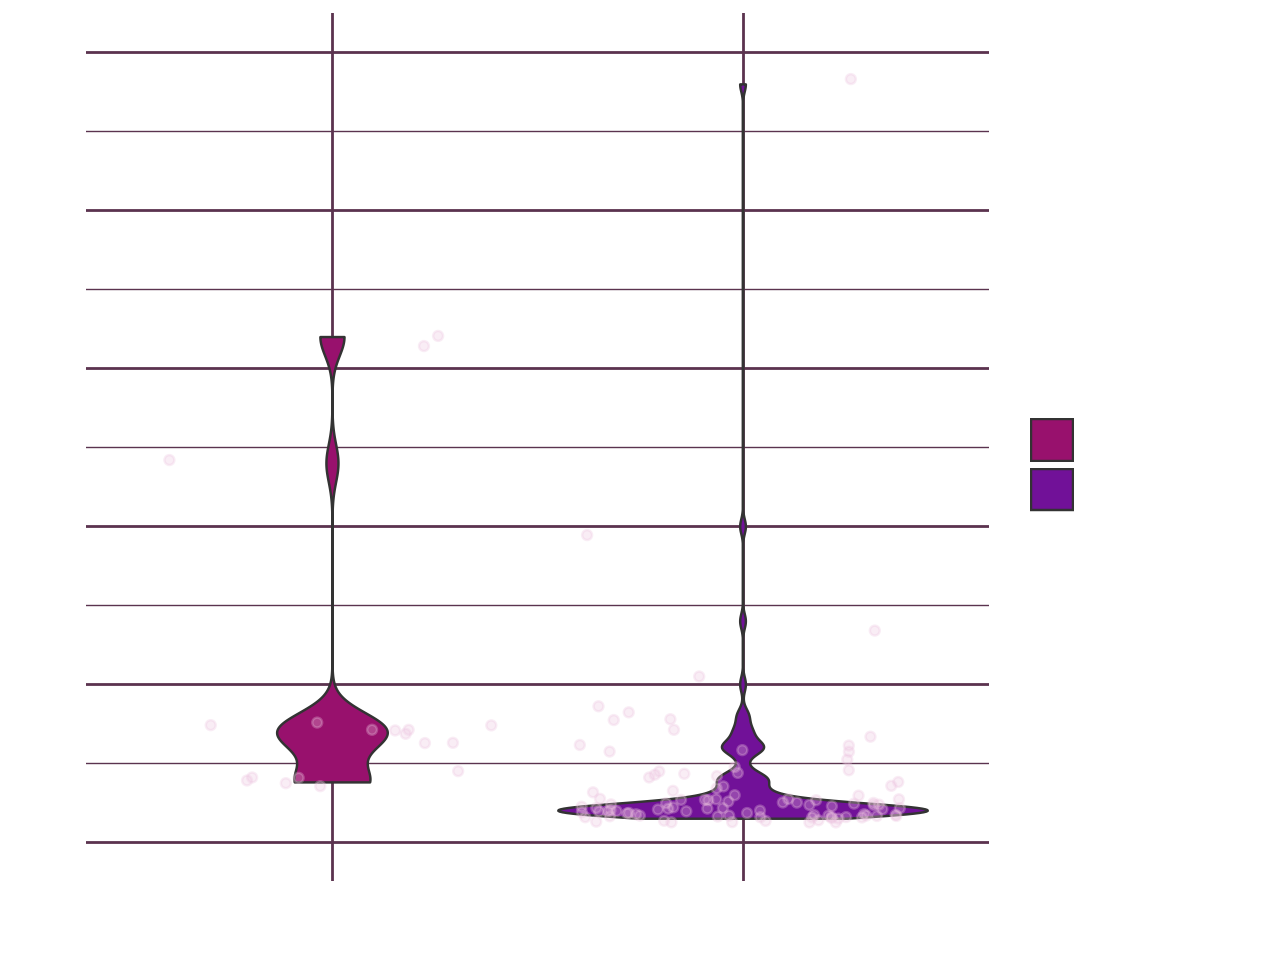

In [37]:
ggplot(aes("Type of Product", "Price", fill = "Type of Product"), data5) + geom_violin() + ylim(0,25) + geom_jitter(color = "#ECC3DF", fill = "#ECC3DF", alpha = 0.3)\
+ theme_minimal() + scale_fill_manual(["#98116D", "#711198"]) + theme(text=element_text(color = "white")) + scale_color_manual(["#98116D", "#711198"])\
+ theme(panel_grid=element_line(color = "#5B334F"))

# Area Chart

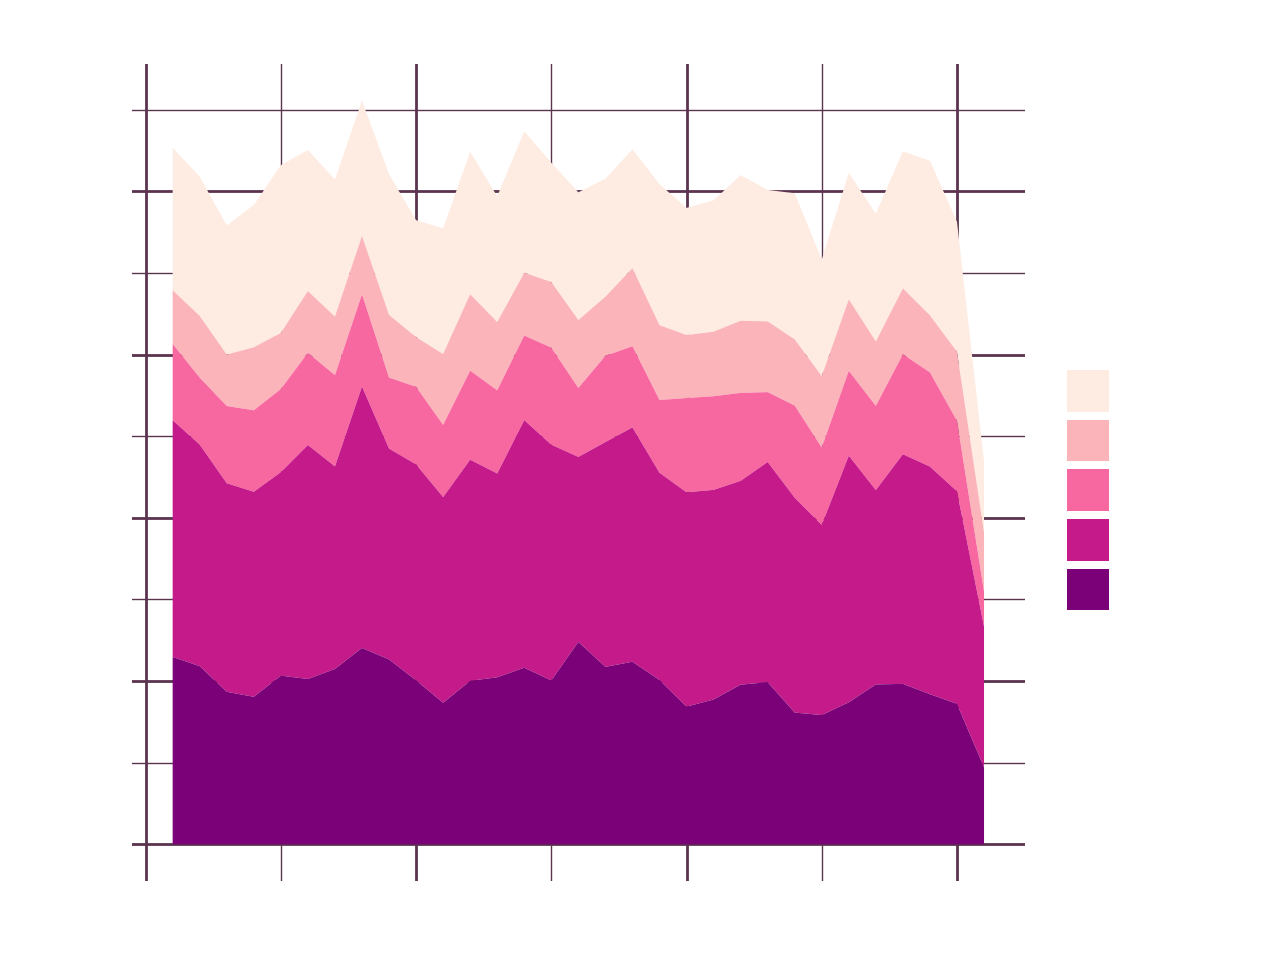

In [38]:
data4 = citiesdataframe.loc[:,["Date","Total Price","Local"]] #extracting the needed columns
data4["Days"] = data4["Date"].dt.day #using datetime to extract the days
data4

data44 = data4.groupby(by = ["Days","Local"],as_index=False).sum(numeric_only=True)
data44

ggplot(aes("Days" ,"Total Price", fill = "Local"),data44)+geom_area()\
+ggtitle("The Change in Total Price over Days for Each City")+labs(fill="Local")\
        +xlab("Days Passed")+ylab("Total Price (money earned)")\
            +scale_fill_brewer(type = "seq", palette= "RdPu")+theme_minimal()\
                +theme(plot_title=element_text(size = 14,color="white"),axis_text_x=element_text(color = "white"),
        axis_text_y=element_text(color="white"),axis_title_x=element_text(color="white"),axis_title_y=element_text(color="white"),
        legend_text=element_text(color="white"),legend_title=element_text(color="white")) + theme(panel_grid=element_line(color = "#5B334F"))

# Count of delivery

In [39]:
data6 = citiesdataframe.dropna(subset = ["Center"])
data6

,index,Date,Number,Local,Terminal Point of Sale,Center,Location,Date of Creation,Type of Document,Client,...,Discount in %,Discount in €,Promotional Code,Discount Code,Tax in %,Surcharge in %,Base Price,Total Price,Ticket Discount in €,Ticket Discount in %
2,2,2019-01-02,TBCN-FS/004624,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:04:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,8.14,8.95,0.0,0.0
3,3,2019-01-02,TBCN-FS/004624,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:04:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,9.55,10.50,0.0,0.0
4,4,2019-01-02,TBCN-FS/004625,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:09:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,9.55,10.50,0.0,0.0
5,5,2019-01-02,TBCN-FS/004626,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:43:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,8.14,8.95,0.0,0.0
6,6,2019-01-02,TBCN-FS/004626,BARCELONA,TPV Barcelona,Glovo,MG1,2019-01-02 14:43:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,2.73,3.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167854,46453,2020-03-17,TV-FS/018136,VALENCIA,TPV Valencia,UberEats,UE1,2020-03-17 20:36:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,6.32,6.95,0.0,0.0
167855,46454,2020-03-17,TV-FS/018136,VALENCIA,TPV Valencia,UberEats,UE1,2020-03-17 20:36:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,10.45,11.50,0.0,0.0
167869,46468,2020-03-18,TV-FS/018140,VALENCIA,TPV Valencia,UberEats,UE1,2020-03-18 13:20:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,27.14,29.85,0.0,0.0
167870,46469,2020-03-18,TV-FS/018141,VALENCIA,TPV Valencia,UberEats,UE1,2020-03-18 13:23:00,Fra. Simp.,NaN,...,0.0,0.0,NaN,NaN,10,1.4,7.23,7.95,0.0,0.0


In [40]:
data66 = data6[["Center", "index"]].groupby(by = ["Center"], as_index = False).count()
data66

,Center,index
0,Glovo,2014
1,Not Take Away,87629
2,Other: Take Away,5354
3,UberEats,6833


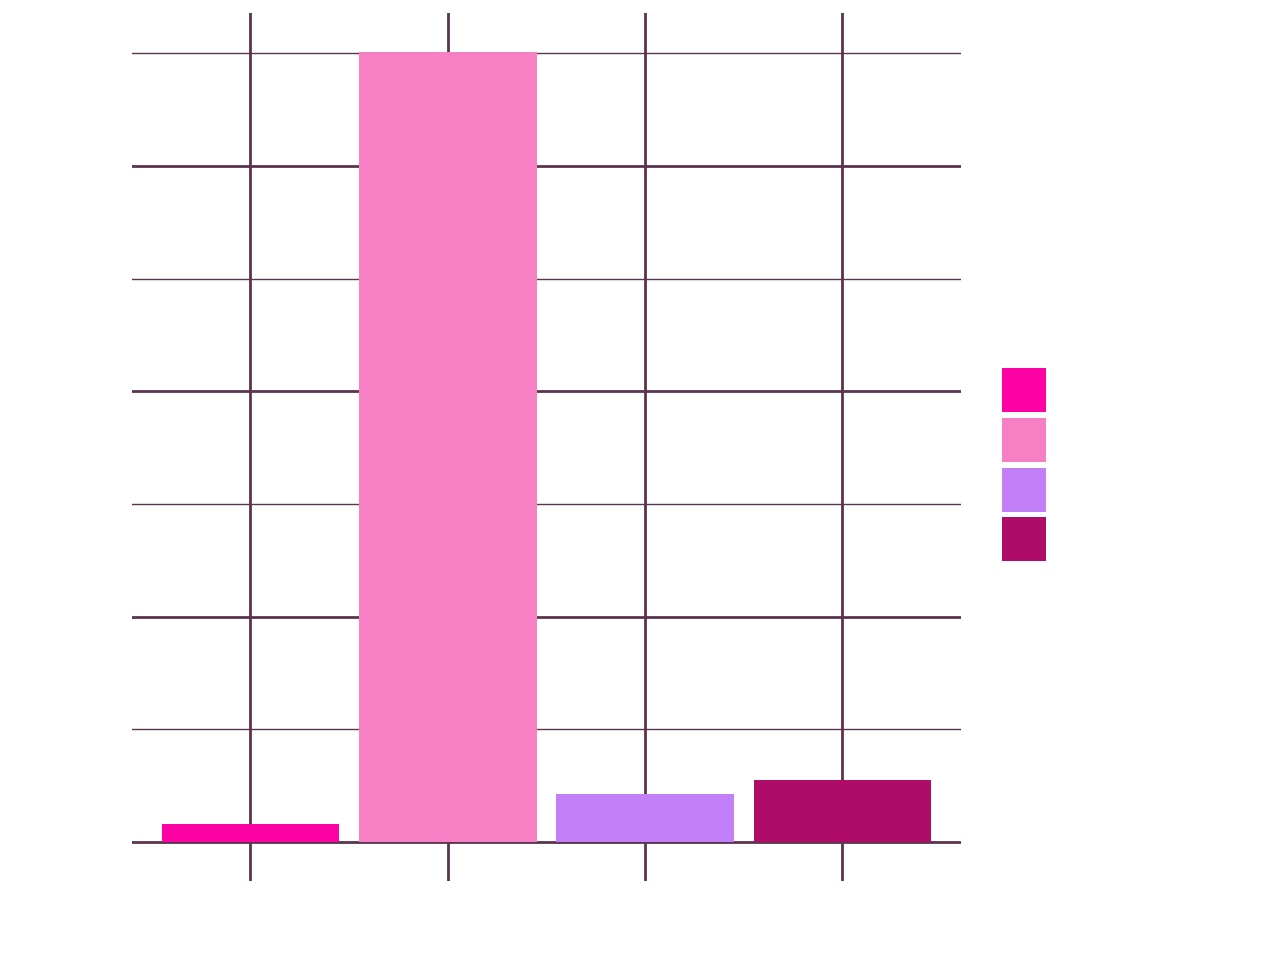

In [41]:
ggplot(aes("Center", "index", fill = "Center"), data66) + geom_col() + scale_fill_manual(["#FC02A4", "#F77FC3", "#C27FF7", "#AF0B69"])\
+ theme_minimal() + theme(text=element_text(color = "white")) + xlab("Dining Option") + theme(panel_grid=element_line(color = "#5B334F"))\
+ ylab("Number of Purchases")